In [2]:
import os
import io
import requests
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# print(os.getcwd())

In [106]:

cluster_id = pd.read_csv(r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Summer_Institute_clones\NeuralNgen\gauge_pos_cluster_climate.csv", sep=';')
cluster_id['gauge_id'] = cluster_id['gauge_id'].astype(str).map(lambda x: '0' + x if not x.startswith('0') else x)
cluster_id

,gauge_id,gauge_lat,gauge_lon,gauge_cluster,Aridity,seasonality,precip_as_snow
0,01022500,44.60797,-67.93524,9,0.436362,0.961675,0.338759
1,01031500,45.17501,-69.31470,9,0.469102,0.898401,0.385287
2,01047000,44.86920,-69.95510,9,0.421674,1.021635,0.305575
3,01052500,44.87739,-71.05749,9,0.525125,0.708425,0.360137
4,01054200,44.39044,-70.97964,9,0.464267,0.791981,0.296226
...,...,...,...,...,...,...,...
638,014309500,42.80400,-123.61091,5,0.282687,1.833706,0.000000
639,014316700,43.34984,-122.72894,5,0.113291,1.806004,0.000000
640,014325000,42.89150,-124.07065,5,0.463260,1.802796,0.000000
641,014362250,42.15401,-123.07532,8,-0.114432,1.844031,0.000000


# Call the forcings:

In [62]:
import os
import pandas as pd

def process_files_to_df(base_dir, keep_start):
    dataframes = []
    
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('_lump_nldas_forcing_leap.txt'):
                file_path = os.path.join(root, file)
                with open(file_path, 'r') as f:
                    lines = f.readlines()
                header = lines[:4]
                # Dynamically set end_keep to the last line
                end_keep = len(lines)  # Total lines in the file
                main_content = lines[keep_start-1:end_keep]
                if main_content:
                    data = [line.strip().split('\t') for line in main_content if line.strip()]
                    if data:
                        df = pd.DataFrame(data, columns=header[3].strip().split('\t'))
                        basin_id = file.split('_')[0]
                        df['gauge_id'] = basin_id
                        # Split and combine date/time into 'time'
                        date_parts = df['Year Mnth Day Hr'].str.split()
                        df['time'] = pd.to_datetime(date_parts.str[0] + '-' + date_parts.str[1] + '-' + date_parts.str[2] + ' ' + date_parts.str[3], format='%Y-%m-%d %H')
                        df.drop(columns=['Year Mnth Day Hr'], inplace=True)
                        df.set_index('time', inplace=True)
                        dataframes.append(df)
    if dataframes:
        return pd.concat(dataframes, ignore_index=False)
    return None

base_directory = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Summer_Institute_clones\CAMELS_data_sample\basin_mean_forcing\nldas"
start_keep = 5  # Start after the 4 header lines

result_df = process_files_to_df(base_directory, start_keep)
result_df#.head(3)

,Dayl(s),PRCP(mm/day),SRAD(W/m2),SWE(mm),Tmax(C),Tmin(C),Vp(Pa),gauge_id
time,,,,,,,,
1993-09-29 12:00:00,41472.00,0.89,184.02,0.00,8.64,8.64,862.86,01013500
1993-09-30 12:00:00,41126.40,0.89,237.08,0.00,5.93,5.93,681.54,01013500
1993-10-01 12:00:00,41126.40,0.22,264.19,0.00,4.75,4.75,584.49,01013500
1993-10-02 12:00:00,40780.80,2.84,149.61,0.00,7.52,7.52,897.58,01013500
1993-10-03 12:00:00,40621.07,18.13,210.73,0.00,9.48,9.48,1010.68,01013500
...,...,...,...,...,...,...,...,...
2013-09-29 12:00:00,42163.20,0.00,505.88,0.00,19.34,19.34,438.10,10259000
2013-09-30 12:00:00,41817.60,0.00,508.40,0.00,20.84,20.84,415.08,10259000
2013-10-01 12:00:00,41817.60,0.00,502.22,0.00,20.43,20.43,460.01,10259000


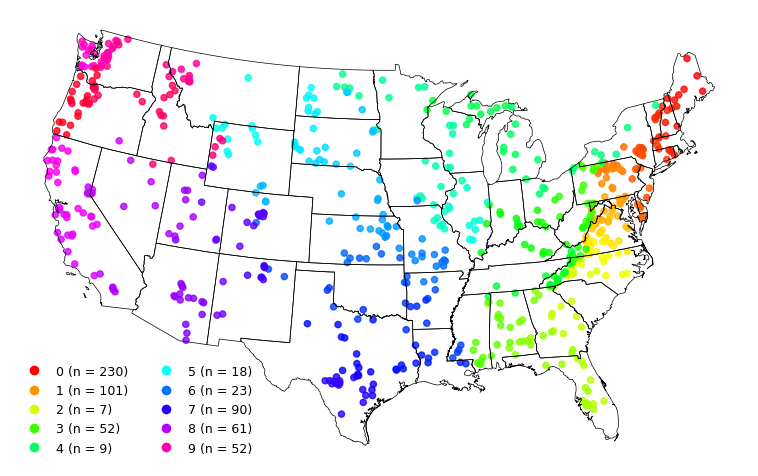

In [84]:

# State boundary
states_all = gpd.read_file(r"C:\Users\hdagne1\Box\Mopex_Boundaries\States_shapefile/States_shapefile.shp").to_crs(5070)
states = states_all[~states_all['State_Name'].isin(['ALASKA', 'HAWAII'])]

# Fetch and load data
r = requests.get("https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attributes_v2.0.feather")
attrs = gpd.read_feather(io.BytesIO(r.content))
r = requests.get("https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attrs_v2_streamflow_v1p2.nc")
attrs = attrs.reset_index(drop=False)
# cluster_id = pd.read_csv(r"/home/jovyan/NeuralNgen/gauge_pos_cluster_climate.csv", sep=';')
cluster_id['gauge_id'] = cluster_id['gauge_id'].astype(str).str.strip().str.zfill(8)
attrs['gauge_cluster'] = cluster_id['gauge_cluster']
# attrs = attrs.merge(cluster_id, on='gauge_id')

# Re-project to a projected CRS before calculating centroid
attrs = attrs.to_crs(5070)  # EPSG:5070 is a suitable projected CRS for the US
attrs['geometry_points'] = attrs['geometry'].centroid
attrs = attrs.set_geometry('geometry_points')

# Drop the original geometry column
attrs = attrs.drop(columns=['geometry'])

# Plotting
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)
states.to_crs(5070).boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)


# Plot the points (USGS sites) from attrs, colored by gauge_cluster
scatter = attrs.plot(ax=ax, markersize=20, label='USGS Sites clusters', marker='o', lw=1, alpha=0.8, c=attrs['gauge_cluster'], cmap='hsv')

# Assuming 'states' is defined elsewhere (e.g., a GeoDataFrame of US states)
# states.to_crs(5070).boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)

# Create custom legend with proxy artists for each cluster using 'hsv' colormap
unique_clusters = sorted(attrs['gauge_cluster'].dropna().unique())  # Filter out NaN
colors = [plt.cm.hsv(i / len(unique_clusters)) for i in range(len(unique_clusters))]  # Use 'hsv' colormap
# Count catchments per cluster and create labels
cluster_counts = attrs['gauge_cluster'].value_counts()
legend_labels = [f'{int(cluster)} (n = {cluster_counts[cluster]})' for cluster in unique_clusters if not pd.isna(cluster)]
patches = [Line2D([0], [0], marker='o', color='w', lw=1, markerfacecolor=colors[i], markersize=8, label=legend_labels[i]) for i in range(len(unique_clusters))]
ax.legend(handles=patches, frameon=False, loc='lower left', fontsize=9, ncol=2)

plt.tight_layout()
ax.set_axis_off()
plt.show()
# fig.savefig('RSME_SCE_ML_spatial.png', dpi=600, bbox_inches='tight', facecolor='white')

# Daily Data --NLDAS from Model_output: 1984-2014:

In [ ]:
os.chdir(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Data\CAMELS\basin_timeseries_v1p2_modelOutput_nldas\model_output_nldas\model_output\flow_timeseries')

def read_basin_forcing(file_path, expected_columns=None):
    try:
        # Assuming the file has a header with the correct column names
        df = pd.read_csv(file_path, sep='\s+') # , skiprows=3
        # Reindexing only if expected_columns is provided and not matching
        if expected_columns is not None and list(df.columns) != expected_columns:
            df = df.reindex(columns=expected_columns)
        return df
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def import_nldas_forcings(base_folder):
    nldas_folder = os.path.join(base_folder, 'nldas')
    all_data = []
    expected_columns = None  # This will be set after reading the first file

    for root, dirs, files in os.walk(nldas_folder):
        for file in files:
            if file.endswith('_05_model_output.txt'):
                full_path = os.path.join(root, file)
                df = read_basin_forcing(full_path, expected_columns)

                if df is not None:
                    if expected_columns is None:
                        expected_columns = df.columns.tolist()

                    gauge_id = file.split('_')[0]
                    df.insert(0, 'gauge_id', gauge_id)
                    all_data.append(df)

    nldas_ModelOutput_all = pd.concat(all_data, ignore_index=True)
    return nldas_ModelOutput_all

# Update the base folder path as per your directory structure
base_folder = r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Data\CAMELS\basin_timeseries_v1p2_modelOutput_nldas\model_output_nldas\model_output\flow_timeseries'

# Import data using the updated function
nldas_ModelOutput_all = import_nldas_forcings(base_folder)

# Ensure the necessary columns are present before creating the 'Date' column
if all(col in nldas_ModelOutput_all.columns for col in ['YR', 'MNTH', 'DY']):
    # Create a 'Date' column from 'YR', 'MNTH', and 'DY'
    nldas_ModelOutput_all['Date'] = pd.to_datetime(
        nldas_ModelOutput_all['YR'].astype(str) + '-' +
        nldas_ModelOutput_all['MNTH'].astype(str).str.zfill(2) + '-' +
        nldas_ModelOutput_all['DY'].astype(str).str.zfill(2)
    )
    # Drop the original 'YR', 'MNTH', and 'DY' columns
    nldas_ModelOutput_all.drop(['YR', 'MNTH', 'DY', 'HR'], axis=1, inplace=True)
    nldas_ModelOutput_all = nldas_ModelOutput_all[['Date', 'gauge_id', 'SWE', 'PRCP', 'RAIM', 'TAIR', 'PET', 'ET', 'MOD_RUN', 'OBS_RUN']]

# Subsetting with date 1984-01-01':'2014-12-31
nldas_ModelOutput_all.set_index('Date', inplace=True)
nldas_ModelOutput_all.index = pd.to_datetime(nldas_ModelOutput_all.index)
nldas_ModelOutput_all = nldas_ModelOutput_all.sort_index()
nldas_ModelOutput_daily_all = nldas_ModelOutput_all.loc['1984-01-01':'2014-12-31']
nldas_ModelOutput_daily_all.reset_index(inplace=True)

# Filter for 1984-2003:
nldas_ModelOutput_daily_all_1984_2003 = nldas_ModelOutput_daily_all[
    (nldas_ModelOutput_daily_all['Date'] >= '1984-01-01') & 
    (nldas_ModelOutput_daily_all['Date'] <= '2014-12-31')
]
nldas_ModelOutput_daily_all_1984_2003['gauge_id'] = nldas_ModelOutput_daily_all_1984_2003['gauge_id'].astype(str).map(lambda x: '0' + x if not x.startswith('0') else x)
nldas_ModelOutput_daily_all_1984_2003.head()

,Date,gauge_id,SWE,PRCP,RAIM,TAIR,PET,ET,MOD_RUN,OBS_RUN
0,1984-01-01,02430085,8.0362,0.00,0.3049,-0.55,0.5982,0.5872,1.9603,1.9262
1,1984-01-01,01052500,162.2174,0.01,0.0550,-13.47,0.0485,0.0471,1.1141,1.3989
2,1984-01-01,06623800,552.3756,0.28,0.1501,-12.44,0.3974,0.2390,0.2793,0.3380
3,1984-01-01,11143000,0.0000,0.00,0.0000,8.72,0.8848,0.8779,4.9623,6.3815
4,1984-01-01,05131500,74.7998,0.00,0.0000,-15.05,0.0739,0.0615,0.0428,0.1941


# Merge NLDAS daily with cathcment clusters:

In [100]:

nldas_ModelOutput_daily_all_1984_2003_clusters = nldas_ModelOutput_daily_all_1984_2003.merge(
    cluster_id[['gauge_id', 'gauge_cluster']],  
    on='gauge_id',
    how='left' 
)

nldas_ModelOutput_daily_all_1984_2003_clusters = nldas_ModelOutput_daily_all_1984_2003_clusters.dropna()

In [103]:
nldas_ModelOutput_daily_all_1984_2003_clusters

,Date,gauge_id,SWE,PRCP,RAIM,TAIR,PET,ET,MOD_RUN,OBS_RUN,gauge_cluster
0,1984-01-01,02430085,8.0362,0.00,0.3049,-0.55,0.5982,0.5872,1.9603,1.9262,0.0
1,1984-01-01,01052500,162.2174,0.01,0.0550,-13.47,0.0485,0.0471,1.1141,1.3989,9.0
2,1984-01-01,06623800,552.3756,0.28,0.1501,-12.44,0.3974,0.2390,0.2793,0.3380,3.0
5,1984-01-01,05458000,48.4073,0.09,0.1500,-9.57,0.1855,0.1841,0.3702,0.3366,1.0
6,1984-01-01,08079600,0.0000,0.00,0.0000,1.28,0.9895,0.2177,0.0008,0.0000,1.0
...,...,...,...,...,...,...,...,...,...,...,...
7539119,2014-12-31,012414500,105.9257,0.00,0.1012,-15.58,0.0216,0.0215,2.4636,0.0000,3.0
7539120,2014-12-31,04122500,0.0330,0.08,0.0500,-10.25,0.1321,0.1297,1.2340,0.0000,0.0
7539121,2014-12-31,04124000,3.0164,1.41,0.0516,-11.12,0.0845,0.0760,1.5234,0.0000,1.0
7539122,2014-12-31,04057800,72.8954,0.00,0.0542,-17.43,0.0389,0.0291,0.4808,0.0000,1.0


In [ ]:
from hourlycamelsus_aorc_Ngen import HourlyCamelsUS, Config
from pathlib import Path